In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv("../data/cleaned/All_country_data_cleaned.csv")
df.head()

,Country Name,Country Code,Counterpart-Area Name,Counterpart-Area Code,Series Name,Series Code,Year,Value
0,Afghanistan,AFG,World,WLD,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2000,3.873397e+09
1,Afghanistan,AFG,World,WLD,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2001,3.873397e+09
2,Afghanistan,AFG,World,WLD,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2002,3.873397e+09
3,Afghanistan,AFG,World,WLD,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2003,3.873397e+09
4,Afghanistan,AFG,World,WLD,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2004,3.873397e+09


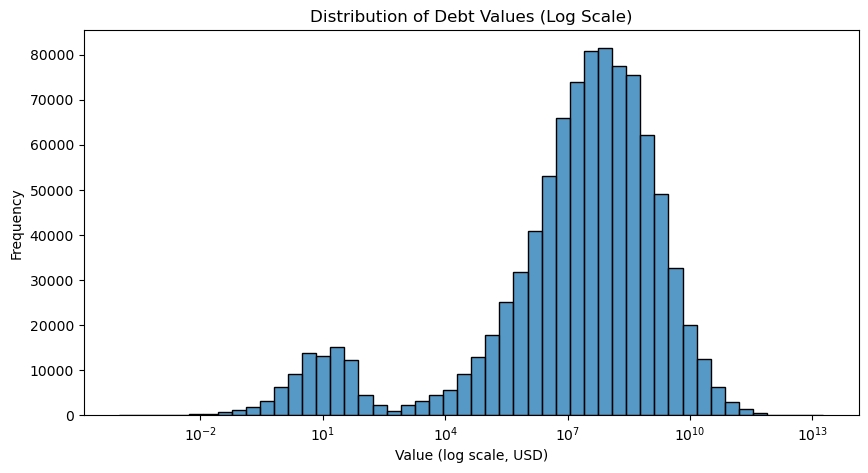

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df["Value"] > 0]["Value"], log_scale=True, bins=50)
plt.title("Distribution of Debt Values (Log Scale)")
plt.xlabel("Value (log scale, USD)")
plt.ylabel("Frequency")
plt.show()

C:\Users\pc-admin\AppData\Local\Temp\ipykernel_16444\1618073629.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


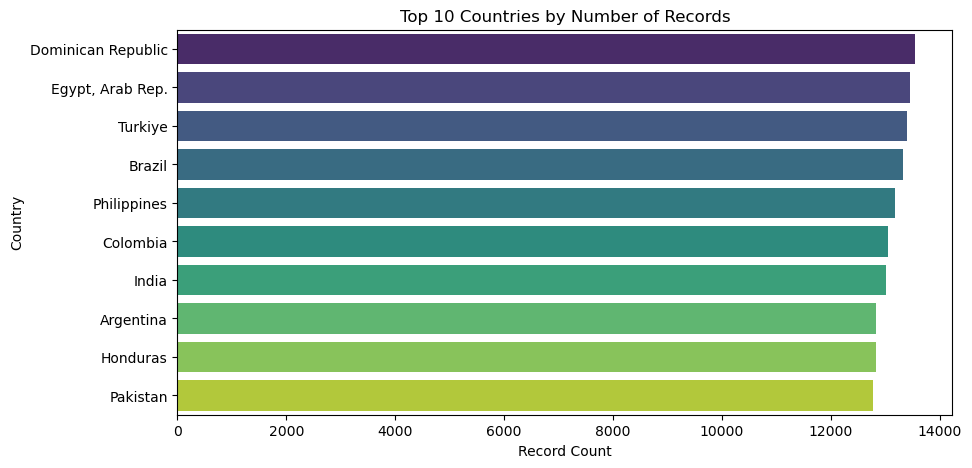

In [4]:
top_countries = df["Country Name"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 10 Countries by Number of Records")
plt.xlabel("Record Count")
plt.ylabel("Country")
plt.show()

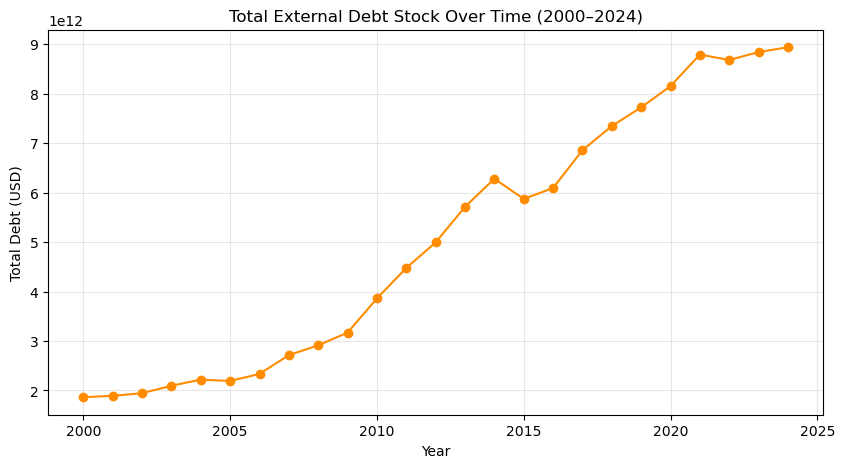

In [5]:
trend = df[df["Series Code"] == "DT.DOD.DECT.CD"].groupby("Year")["Value"].sum()

plt.figure(figsize=(10, 5))
trend.plot(kind="line", marker="o", color="darkorange")
plt.title("Total External Debt Stock Over Time (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Total Debt (USD)")
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\pc-admin\AppData\Local\Temp\ipykernel_16444\1750794965.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_indicators.values, y=top_indicators.index, palette="magma")


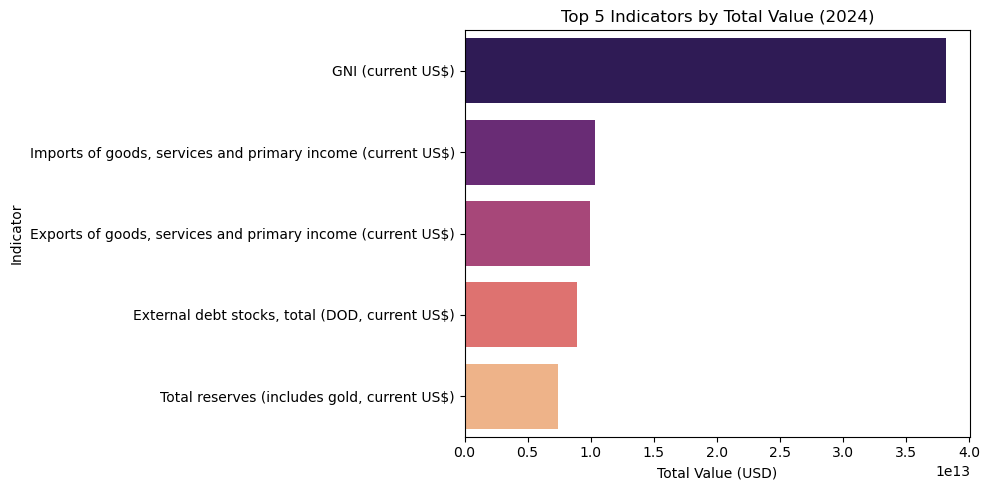

In [6]:
top_indicators = (
    df[df["Year"] == 2024]
    .groupby("Series Name")["Value"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_indicators.values, y=top_indicators.index, palette="magma")
plt.title("Top 5 Indicators by Total Value (2024)")
plt.xlabel("Total Value (USD)")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()

In [8]:
## #EDA Summary — Key Insights

#1. **Debt values span an extreme range** (from negative net-flow figures to trillions in stock indicators) because the dataset blends fundamentally different indicator types (dollars, percentages, years) — any meaningful analysis must filter to a specific indicator.
#2. **Data coverage is strong** across most countries, with the top countries having near-complete records across all 25 years and 576 indicators.
#3. **Global external debt stock has grown roughly 4x since 2000** (~$2T → ~$8.94T by 2024), with a visible dip around 2014–2015 and acceleration afterward.
#4. **A small number of indicators dominate total debt value** — primarily large-scale stock and flow indicators (external debt stocks, GNI, imports/exports) rather than smaller metrics like grace periods or interest rates.